# 09. Fourth down: win probability and go / kick / punt (M7a)

**License.** Sections 1-3 (the win-probability model) and the kicking curves use play-by-play and A4s only: **CC BY 4.0**. Everything about the go-for-it option, the recommendations and the audit uses the M6 play model (nflverse participation data: NFL Next Gen Stats via nflverse 2016-2022, FTN Data via nflverse 2023+), so those outputs are **CC BY-SA 4.0**.

The question: *on fourth down, should the team go for it, kick a field goal, or punt?* The method is `context/ml-m7-method.md` (sections 2 and 3); results are in `context/ml.md` ("M7a build notes").

1. Win probability from first principles
2. Our WP model: inputs, monotone constraints, and why no isotonic step
3. Dev results against nflfastR's `wp` and `vegas_wp`
4. Valuing each option: go, field goal, punt
5. The uncertainty band and "toss-ups"
6. A worked example: a real 2019 fourth down
7. The decision audit (model-estimated)

Everything here uses development seasons only (WP and kicking 2016-2019, fourth downs 2018-2019). The holdout (2020-2025) is not touched.

In [1]:
import json
import sys
import warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nflelo").is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier

import ml_m7a
from nflelo.ml import data as D
from nflelo.ml.decisions import fourth as fd, kicking as kk
from nflelo.ml.eval import calibration
from nflelo.ml.plays import data as pdata
from nflelo.ml.wp import model as wpm

plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
pd.set_option("display.width", 170)
INK, ACCENT, MUTED, BAD, MODEL = "#1f2a44", "#2f6fdf", "#9aa3b2", "#d1495b", "#2a9d8f"
OUT = D.ML_DIR / "m7a"
DEV = json.loads((OUT / "dev.json").read_text())
FOURTH = pd.read_parquet(OUT / "fourth_m7adev.parquet")
WPF = pd.read_parquet(OUT / "wp_m7adev.parquet")

inp = ml_m7a.load_inputs(2019)       # play-by-play 1999-2019, A4s walk-forward, WP states, M6 table (dev data only)
T = inp.wp_table
print(f"WP states 2006-2019: {len(T):,}; dev fourth downs valued: {len(FOURTH):,}")

inputs through 2019: pbp 984,639 rows, A4s 3,584 games, WP states 529,839, M6 plays 111,961 (15s)


WP states 2006-2019: 529,839; dev fourth downs valued: 7,171


## 1. Win probability from first principles

Win probability (WP) is the chance that the team with the ball wins, given everything known at the snap. The simplest estimate is a lookup: among past plays in the same situation, how often did that team win? The lookup works for common situations and falls apart for rare ones, so a model smooths it. The plot shows the raw lookup from the training seasons (2006-2015): the same lead is worth much more late in a game.

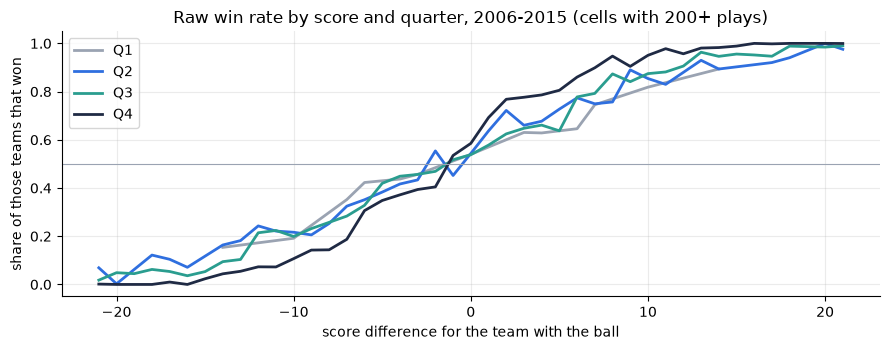

In [2]:
tr = T[T["season"].between(2006, 2015)]
fig, ax = plt.subplots()
for q, col in zip((1, 2, 3, 4), (MUTED, ACCENT, MODEL, INK)):
    g = tr[tr["qtr"] == q].assign(sd=lambda d: d["score_diff"].clip(-21, 21)).groupby("sd")["y"].agg(["mean", "size"])
    g = g[g["size"] >= 200]
    ax.plot(g.index, g["mean"], color=col, lw=2, label=f"Q{q}")
ax.axhline(0.5, color=MUTED, lw=0.8)
ax.set_xlabel("score difference for the team with the ball"); ax.set_ylabel("share of those teams that won")
ax.set_title("Raw win rate by score and quarter, 2006-2015 (cells with 200+ plays)"); ax.legend()
plt.tight_layout(); plt.show()

A 7-point lead wins about two thirds of the time in the first quarter and more than 90% of the time in the fourth. A model has to learn that interaction, plus field position, down and distance, timeouts, who gets the second-half kickoff, and how good the two teams are.

**Team strength without the betting line.** nflfastR's `vegas_wp` uses the point spread; our models never use market data (decision D3). Instead the pregame strength is the **A4s probability** for the team with the ball, walk-forward: for a 2019 game it comes from the A4s fit on seasons before 2019, with features as of that week. Its weight fades as the game goes on (`strength_time` = logit(A4s) x exp(-4 x elapsed share)), the same shape nflfastR uses for the spread.

## 2. The model: inputs and monotone constraints

Gradient boosting (scikit-learn's `HistGradientBoostingClassifier`, log loss, trees chosen by early stopping on the season before the target) on 14 inputs. Some relationships can never run backwards: more points, a stronger team, a better field position, an extra timeout, fewer yards to go. **Monotone constraints** force the trees to respect them. Without them, a tree can learn noise such as "being at the opponent's 33 is worse than at the 35", and a fourth-down comparison built on such wiggles would be wrong for reasons that have nothing to do with football.

        feature constraint
     score_diff increasing
      game_secs       free
      half_secs       free
          half2       free
           down decreasing
        ydstogo decreasing
   yardline_100 decreasing
   pos_timeouts increasing
   def_timeouts decreasing
  receive_2h_ko       free
           home       free
       a4s_prob increasing
diff_time_ratio increasing
  strength_time increasing


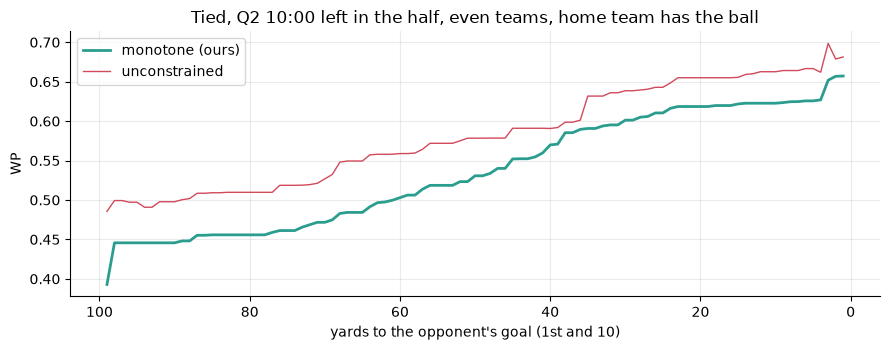

spots (of 98) where WP RISES when the ball moves a yard farther from the goal: unconstrained 5, ours 0


In [3]:
print(pd.DataFrame({"feature": wpm.FEATURES, "constraint": [{1: "increasing", -1: "decreasing", 0: "free"}[wpm.MONOTONE.get(f, 0)] for f in wpm.FEATURES]}).to_string(index=False))

S = 2019
m = wpm.without_calibration(wpm.fit_season_ahead(T, S))
tr = T[T["season"].between(2006, S - 1)]
free = HistGradientBoostingClassifier(max_iter=m.info["n_iter"], early_stopping=False, random_state=wpm.SEED, **wpm.PARAMS)
free.fit(tr[wpm.FEATURES].to_numpy(float), tr["y"].to_numpy(int))

base = dict(score_diff=0.0, game_secs=2400.0, half_secs=600.0, half2=0.0, down=1.0, ydstogo=10.0, pos_timeouts=3.0,
            def_timeouts=3.0, receive_2h_ko=0.0, home=1.0, a4s_prob=0.5)
grid = np.arange(1, 100)
states = wpm.add_derived(pd.DataFrame([{**base, "yardline_100": float(y), "ydstogo": float(min(10, y))} for y in grid]))
fig, ax = plt.subplots()
ax.plot(grid, m.predict(states), color=MODEL, lw=2, label="monotone (ours)")
ax.plot(grid, free.predict_proba(states[wpm.FEATURES].to_numpy(float))[:, 1], color=BAD, lw=1, label="unconstrained")
ax.invert_xaxis(); ax.set_xlabel("yards to the opponent's goal (1st and 10)"); ax.set_ylabel("WP")
ax.set_title("Tied, Q2 10:00 left in the half, even teams, home team has the ball"); ax.legend()
plt.tight_layout(); plt.show()
u = free.predict_proba(states[wpm.FEATURES].to_numpy(float))[:, 1]
ours = m.predict(states)
print(f"spots (of 98) where WP RISES when the ball moves a yard farther from the goal: "
      f"unconstrained {(np.diff(u) > 1e-9).sum()}, ours {(np.diff(ours) > 1e-9).sum()}")

**Isotonic calibration was built, then not used.** The spec asked for an isotonic map fit on a validation season inside the training window. It is fitted and reported for every season, but on every dev season it made the Brier score worse (by 0.0007 to 0.0015), as did a three-season and a cross-fitted version. A log-loss boosted model is already close to calibrated, and one season's play outcomes are only about 256 game results, so the map mostly learns that season's noise. The frozen model is the raw boosted model (`wpm.CALIBRATE = False`).

In [4]:
rows = []
for s_, v in DEV["per_season"].items():
    mm = v["wp"]["models"]
    rows.append({"season": s_, "m7a (raw)": mm["m7a_wp"]["brier"], "m7a + isotonic": mm["m7a_wp_isotonic"]["brier"],
                 "nflfastR wp": mm["nflfastr_wp"]["brier"], "vegas_wp": mm["vegas_wp"]["brier"], "plays": v["wp"]["n"]})
pd.DataFrame(rows).round(4)

,season,m7a (raw),m7a + isotonic,nflfastR wp,vegas_wp,plays
0,2016,0.1543,0.1553,0.1638,0.1532,38012
1,2017,0.1350,0.1359,0.1489,0.1277,38084
2,2018,0.1453,0.1468,0.1536,0.1393,37192
3,2019,0.1406,0.1413,0.1519,0.1366,37912


## 3. Dev results: our WP against nflfastR

Season-ahead, REG 2018-2019, on the plays where nflfastR reports both benchmarks. CIs resample whole games (a game's plays share one outcome). nflfastR's `wp` was trained on all seasons including these, and `vegas_wp` uses the point spread; both are benchmarks only.

                  Brier  log loss     ECE
m7a_wp           0.1429    0.4356  0.0047
m7a_wp_isotonic  0.1440    0.4480  0.0152
nflfastr_wp      0.1527    0.4556  0.0121
vegas_wp         0.1380    0.4174  0.0108
m7a_wp-nflfastr_wp       Brier diff -0.0098 [-0.0180, -0.0014]
m7a_wp-vegas_wp          Brier diff +0.0049 [+0.0004, +0.0094]
m7a_wp-isotonic          Brier diff -0.0011 [-0.0019, -0.0003]


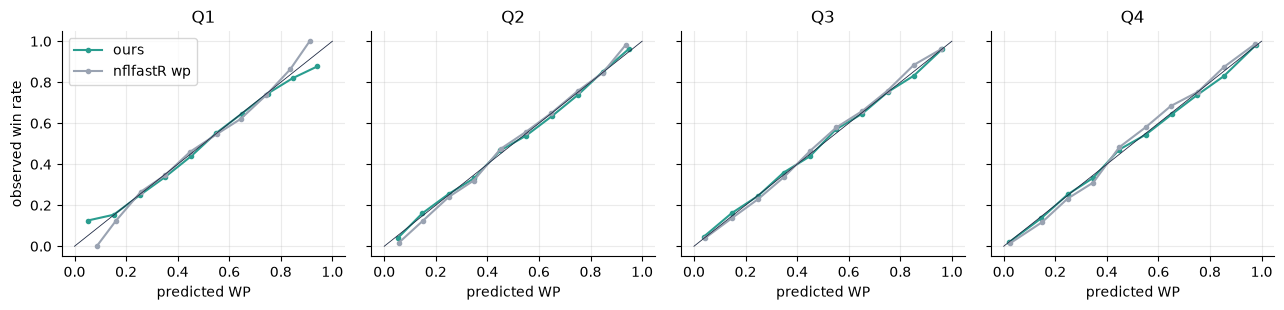

In [5]:
w = DEV["primary"]["wp"]
tab = pd.DataFrame({k: {"Brier": v["brier"], "log loss": v["logloss"], "ECE": v["cal"]["ece"]} for k, v in w["models"].items()}).T
print(tab.round(4))
for k, d in w["diffs"].items():
    b = d["brier"]
    print(f"{k:<24} Brier diff {b['diff']:+.4f} [{b['ci_low']:+.4f}, {b['ci_high']:+.4f}]")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
f = WPF[WPF["season"] >= 2018]
for ax, q in zip(axes, (1, 2, 3, 4)):
    h = f[f["qtr"] == q]
    for col, c, lab in (("p_wp", MODEL, "ours"), ("bench_wp", MUTED, "nflfastR wp")):
        r = calibration.reliability_table(h["y"], h[col].fillna(0.5), bins=10)
        ax.plot(r["mean_pred"], r["observed"], "o-", color=c, ms=3, label=lab)
    ax.plot([0, 1], [0, 1], color=INK, lw=0.6); ax.set_title(f"Q{q}"); ax.set_xlabel("predicted WP")
axes[0].set_ylabel("observed win rate"); axes[0].legend(); plt.tight_layout(); plt.show()

Our model beats nflfastR's `wp` (it knows how good the teams are) and trails `vegas_wp` (the market knows more than A4s). Play-level calibration needs care: the play outcomes of one game are one outcome, so the usual "calibrated forecaster" null band (independent coin flips per play) is far too narrow. The record also shows a game-clustered null for reference.

## 4. Valuing each option

For each fourth down the engine computes the team's WP after each choice, using models fit only on earlier seasons.

**Go for it.** M6 (the call-conditioned play model) gives a full yards distribution for a run and for a pass. The pre-snap structure of a play that never happened is unknown, so each call averages over 16 personnel / formation / box configurations drawn from training third and fourth downs at that distance. Run and pass are mixed by how often teams actually ran on fourth-down attempts at that distance. Every yards bin then leads to a state: converted (1st and 10 at the new spot), touchdown (+7, opponent's ball after the kickoff), or failed (opponent's ball at the spot).

run share by distance bucket (1, 2, 3, 4-5, 6-9, 10+): [0.73 0.23 0.1  0.1  0.11 0.07]
clock seconds to the next snap by outcome: {'go_conv': 8.0, 'go_td': 32.0, 'go_fail': 6.0, 'fg_make': 5.0, 'fg_miss': 5.0, 'punt': 9.0}
kickoff start after a score: this season's running mean from earlier weeks (2018's mean 74.3 yards to go is the week-1 fallback)


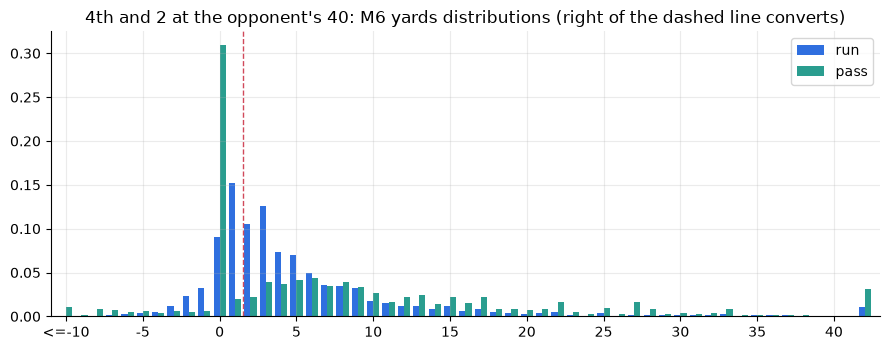

 p_conv_run  p_conv_pass  share_run  p_conv  wp_go  wp_fg  wp_punt
      0.674         0.61      0.226   0.624  0.535  0.485    0.492


In [6]:
comp, tables = fd.fit_components(S, inp.pbp, inp.wp_table, inp.m6_table, wp=m)
print("run share by distance bucket (1, 2, 3, 4-5, 6-9, 10+):", np.round(comp.run_share, 2))
print("clock seconds to the next snap by outcome:", comp.dur)
print(f"kickoff start after a score: this season's running mean from earlier weeks (2018's mean {comp.ko_spot:.1f} "
      f"yards to go is the week-1 fallback)")

def one(**kw):
    d = dict(game_id="x", play_id=1, season=2019, week=8, posteam="KC", defteam="DEN", qtr=2, score_diff=0.0,
             game_secs=2400.0, half_secs=600.0, half2=0.0, down=4.0, ydstogo=2.0, yardline_100=40.0, pos_timeouts=3.0,
             def_timeouts=3.0, receive_2h_ko=0.0, home=1.0, a4s_prob=0.5, indoor=0.0, wind_out=5.0, cold=0.0,
             roof_open=0.0, temp=60.0, wind=5.0, gkey=201908, kicker=None, punter=None)
    d.update(kw)
    return pd.DataFrame([d])

dec = one()
gi = fd.go_inputs(dec, comp, inp.ratings)
mix, run, pas = fd.go_distribution(comp.yards, gi, 1)
fig, ax = plt.subplots()
x = np.arange(pdata.N_BINS)
ax.bar(x - 0.2, run[0], width=0.4, color=ACCENT, label="run")
ax.bar(x + 0.2, pas[0], width=0.4, color=MODEL, label="pass")
ax.axvline(pdata.BIN_LABELS.index("2") - 0.5, color=BAD, ls="--", lw=1)
ax.set_xticks(x[::5]); ax.set_xticklabels(pdata.BIN_LABELS[::5]); ax.set_xlim(-1, 53)
ax.set_title("4th and 2 at the opponent's 40: M6 yards distributions (right of the dashed line converts)")
ax.legend(); plt.tight_layout(); plt.show()
v = fd.option_values(comp, dec, gi)
print(v[["p_conv_run", "p_conv_pass", "share_run", "p_conv", "wp_go", "wp_fg", "wp_punt"]].round(3).to_string(index=False))

After a score the opponent's start is the kickoff start as of that week: the current season's mean from earlier weeks (or last season's in week 1), so rule changes such as the 2024 dynamic kickoff are picked up within the season.

**Field goal.** A logistic model of the make probability on distance (with bends at 40 and 50 yards), roof, wind, cold, the kicker's shrunk value from earlier games, and the league's level so far this season. A make is +3 and the opponent's ball after the kickoff; a miss gives the opponent the ball at the spot of the kick (8 yards behind the line) or its 20.

**Punt.** A distribution over where the receiving team starts (5-yard bins, touchback at the 20, a return touchdown, or the kicking team keeping the ball), by punt spot, wind and the punter's value. The value of a punt is the average of the opponent-ball WPs over that distribution.

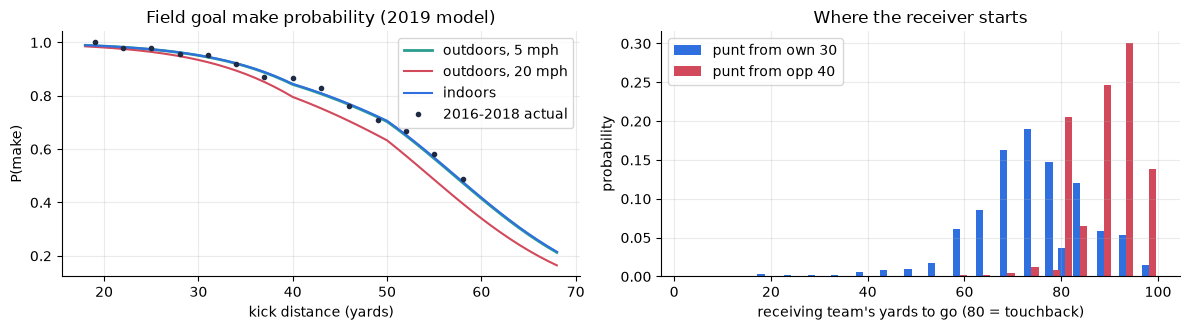

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
dist = np.arange(18, 69)
rows = pd.DataFrame({"dist": dist, "dist_over40": np.maximum(dist - 40, 0), "dist_over50": np.maximum(dist - 50, 0),
                     "indoor": 0.0, "wind_out": 5.0, "cold": 0.0, "kval": 0.0, "lg": 0.0})
axes[0].plot(dist, comp.fg.predict(rows), color=MODEL, lw=2, label="outdoors, 5 mph")
axes[0].plot(dist, comp.fg.predict(rows.assign(wind_out=20.0)), color=BAD, lw=1.5, label="outdoors, 20 mph")
axes[0].plot(dist, comp.fg.predict(rows.assign(indoor=1.0, wind_out=0.0)), color=ACCENT, lw=1.5, label="indoors")
fgr = kk.fg_table(inp.pbp)
fgr = fgr[fgr["season"].between(2016, 2018)].assign(d=lambda t: (t["dist"] // 3) * 3 + 1)
g = fgr.groupby("d")["made"].agg(["mean", "size"]); g = g[g["size"] >= 30]
axes[0].plot(g.index, g["mean"], "o", color=INK, ms=3, label="2016-2018 actual")
axes[0].set_xlabel("kick distance (yards)"); axes[0].set_ylabel("P(make)"); axes[0].legend(); axes[0].set_title("Field goal make probability (2019 model)")
for yl, c in ((70, ACCENT), (40, BAD)):
    px = pd.DataFrame({"yardline_100": [float(yl)], "indoor": [0.0], "wind_out": [5.0], "pval": [0.0], "lgp": [0.0]})
    P = comp.punt.predict(px)[0]
    axes[1].bar(comp.punt.class_r[1:-1] + (0 if yl == 70 else 1.5), P[1:-1], width=1.5, color=c, label=f"punt from {'own ' + str(100 - yl) if yl > 50 else 'opp ' + str(yl)}")
axes[1].set_xlabel("receiving team's yards to go (80 = touchback)"); axes[1].set_ylabel("probability"); axes[1].legend()
axes[1].set_title("Where the receiver starts")
plt.tight_layout(); plt.show()

**Selection bias.** Teams go for it when it looks good, so learning conversion from fourth-down attempts alone would flatter going for it. M6 learned yards from all downs, with down as an input, so its fourth-down estimate leans on the much larger third-down record. The check: predicted against actual conversion on real attempts.

In [8]:
sel = DEV["primary"]["selection"]
pd.DataFrame({k: {"n": v["n"], "predicted": v["pred"], "actual": v["actual"],
                  "actual - predicted": v["actual_minus_pred"]["diff"], "CI low": v["actual_minus_pred"]["ci_low"],
                  "CI high": v["actual_minus_pred"]["ci_high"]} for k, v in sel.items() if v.get("n")}).T.round(3)

,n,predicted,actual,actual - predicted,CI low,CI high
4th_and_1_engine,425.0,0.676,0.659,-0.017,-0.060,0.029
4th_and_1_actual_features,345.0,0.668,0.670,0.002,-0.050,0.052
3rd_and_1_actual_features,1234.0,0.683,0.690,0.008,-0.018,0.034
4th_and_2_engine,144.0,0.542,0.576,0.034,-0.046,0.115
4th_and_2_actual_features,95.0,0.547,0.589,0.042,-0.055,0.140
3rd_and_2_actual_features,853.0,0.565,0.577,0.012,-0.020,0.044
4th_and_1_2_engine,569.0,0.642,0.638,-0.004,-0.042,0.036


## 5. The uncertainty band

Each component is a fitted model, and a refit on slightly different games would give slightly different WPs. The engine refits all four (WP, M6, field goal, punt) on 50 game-resampled copies of the training data and values every fourth down again. The **band** is the 5th-95th percentile of (best option minus second best) across those refits. If the band includes 0, the call is a **toss-up**: the data can't separate the two options.

toss-up share, 2018-2019: 57.4%


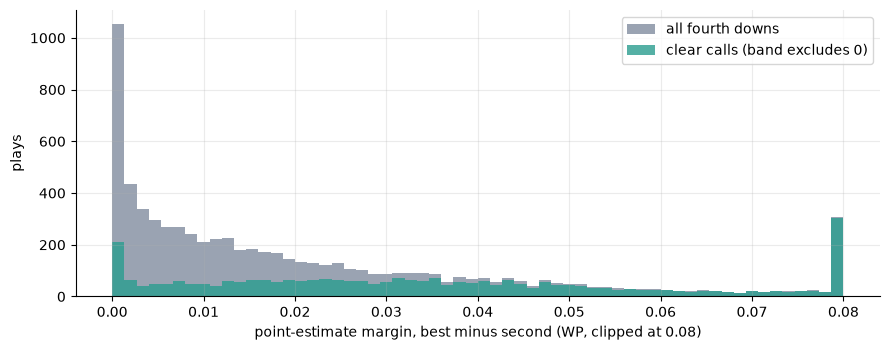

margin
(0.0, 0.005]     0.83
(0.005, 0.01]    0.80
(0.01, 0.02]     0.70
(0.02, 0.05]     0.32
(0.05, 1.0]      0.06
Name: tossup, dtype: float64


In [9]:
print(f"toss-up share, 2018-2019: {FOURTH['tossup'].mean():.1%}")
fig, ax = plt.subplots()
clear = FOURTH[~FOURTH["tossup"]]
ax.hist(FOURTH["margin"].clip(0, 0.08), bins=60, color=MUTED, label="all fourth downs")
ax.hist(clear["margin"].clip(0, 0.08), bins=60, color=MODEL, alpha=0.8, label="clear calls (band excludes 0)")
ax.set_xlabel("point-estimate margin, best minus second (WP, clipped at 0.08)"); ax.set_ylabel("plays"); ax.legend()
plt.tight_layout(); plt.show()
print(FOURTH.groupby(pd.cut(FOURTH["margin"], [0, 0.005, 0.01, 0.02, 0.05, 1]), observed=True)["tossup"].mean().round(2))

## 6. A worked example: a real 2019 fourth down

The fourth down below is the largest model-estimated miss in 2019 among plays the team **punted**. Every number is reproduced from the components fit for 2019 (on 2006-2018 and, for M6, 2016-2018).

In [10]:
ex = FOURTH[(FOURTH["season"] == 2019) & (FOURTH["choice"] == "punt")].sort_values("lost", ascending=False).iloc[0]
print(f"{ex['posteam']} vs {ex['defteam']}, 2019 week {ex['week']}, {ml_m7a.clock(ex['qtr'], ex['game_secs'])}, "
      f"score {ex['score_diff']:+.0f}, 4th and {ex['ydstogo']:.0f}, {ex['yardline_100']:.0f} yards from the goal")
print("what happened:", ex["desc"][:200])
d = fd.decision_table(inp.pbp, inp.a4s, seasons=[2019])
d = d[(d["game_id"] == ex["game_id"]) & (d["play_id"] == ex["play_id"])].reset_index(drop=True)
gi = fd.go_inputs(d, comp, inp.ratings)
v = fd.option_values(comp, d, gi)
print(f"\npregame A4s for {ex['posteam']}: {d['a4s_prob'][0]:.3f}; timeouts {d['pos_timeouts'][0]:.0f} vs {d['def_timeouts'][0]:.0f}")
print(f"GO:   P(convert) {v['p_conv'][0]:.3f} (run {v['p_conv_run'][0]:.3f}, pass {v['p_conv_pass'][0]:.3f}, run share {v['share_run'][0]:.2f}) -> WP {v['wp_go'][0]:.3f}")
print(f"FG:   distance {d['yardline_100'][0] + kk.FG_DIST_OFFSET:.0f} yards, P(make) {v['p_fg'][0]:.3f} -> WP {v['wp_fg'][0]:.3f}")
print(f"PUNT: -> WP {v['wp_punt'][0]:.3f}")
print(f"\nrecommendation {ex['best']}, margin {ex['margin']:.3f}, 90% band [{ex['band_lo']:.3f}, {ex['band_hi']:.3f}], "
      f"{'toss-up' if ex['tossup'] else 'clear call'}; model-estimated WP given up by punting: {ex['lost']:.3f}")

LAC vs CHI, 2019 week 8, Q4 1:45, score +1, 4th and 1, 76 yards from the goal
what happened: (1:45) (Punt formation) 1-T.Long punts 58 yards to CHI 18, Center-45-C.Mazza. 29-T.Cohen to CHI 35 for 17 yards (49-D.Tranquill).



pregame A4s for LAC: 0.313; timeouts 3 vs 1
GO:   P(convert) 0.673 (run 0.736, pass 0.500, run share 0.73) -> WP 0.521
FG:   distance 94 yards, P(make) 0.000 -> WP 0.147
PUNT: -> WP 0.391

recommendation go, margin 0.131, 90% band [0.050, 0.268], clear call; model-estimated WP given up by punting: 0.131


In [11]:
# where the go value comes from: the WP of the next state after each yards outcome
yl, ytg = d["yardline_100"][0], d["ydstogo"][0]
mixp, _, _ = fd.go_distribution(comp.yards, gi, 1)
ys = fd._bin_yards(np.array([yl]))[0]
sb_rows = []
for k in range(pdata.TD_BIN):
    if mixp[0, k] < 0.004:
        continue
    new = yl - ys[k]
    ok = ys[k] >= ytg
    sb = fd.StateBatch(d)
    sb.add("x", [0], ok, new if ok else 100 - new, 0.0, comp.dur["go_conv" if ok else "go_fail"], [1.0])
    sb_rows.append({"yards": pdata.BIN_LABELS[k], "prob": mixp[0, k], "converted": ok, "WP after": sb.evaluate(comp.wp)["x"][0]})
print(pd.DataFrame(sb_rows).round(3).to_string(index=False))
sb = fd.StateBatch(d); sb.add("x", [0], False, comp.ko_spot, fd.TD_POINTS, comp.dur["go_td"], [1.0])
print(f"touchdown: prob {mixp[0, pdata.TD_BIN]:.3f}, WP after {sb.evaluate(comp.wp)['x'][0]:.3f}")

yards  prob  converted  WP after
<=-10 0.004      False     0.127
   -5 0.004      False     0.150
   -4 0.008      False     0.150
   -3 0.015      False     0.151
   -2 0.010      False     0.151
   -1 0.032      False     0.151
    0 0.243      False     0.153
    1 0.062       True     0.678
    2 0.186       True     0.683
    3 0.083       True     0.684
    4 0.056       True     0.684
    5 0.053       True     0.688
    6 0.029       True     0.688
    7 0.027       True     0.702
    8 0.017       True     0.711
    9 0.026       True     0.711
   10 0.017       True     0.713
   11 0.017       True     0.713
   12 0.012       True     0.723
   13 0.010       True     0.725
   14 0.008       True     0.739
   15 0.008       True     0.743
   16 0.004       True     0.748
   17 0.006       True     0.754
   20 0.004       True     0.775
   25 0.006       True     0.798
  41+ 0.006       True     0.857
touchdown: prob 0.004, WP after 0.951


The go value is the probability-weighted average of these next-state WPs. A failed attempt here is costly (the opponent gets the ball close to field-goal range), but a conversion lets the team run down the clock; the punt only moves the opponent back. The band says whether that gap survives refitting the models.

## 7. The decision audit (model-estimated)

For every fourth down of 2018-2019: the recommendation, the team's choice, and the WP the team gave up by its choice **according to the model**. The counterfactual outcome is never observed, so these numbers are estimates, not proof.

In [12]:
a = DEV["primary"]["audit"]
print(f"fourth downs {a['n']:,} in {a['games']} games; choices {a['choice_counts']}; model recommends {a['recommended_counts']}")
print(f"teams matched the recommendation on {a['matched_share']:.1%} ({a['matched_share_clear_calls']:.1%} of clear calls); toss-ups {a['tossup_share']:.1%}")
print(f"model-estimated WP given up: {a['wp_lost_total']:.1f} wins in total, {a['wp_lost_per_team_game']:.4f} per team-game "
      f"(about {a['wp_lost_total'] / 64:.2f} wins per team over the two seasons)")
print(pd.DataFrame(a["crosstab_choice_by_recommended"]).fillna(0).astype(int).rename_axis("choice \\ model"))
top = pd.DataFrame(a["top_misses"])[["season", "week", "posteam", "defteam", "clock", "score_diff", "ydstogo", "yardline_100", "choice", "best", "wp_go", "wp_fg", "wp_punt", "lost", "tossup"]]
top.round(3)

fourth downs 7,171 in 509 games; choices {'punt': 4312, 'fg': 1741, 'go': 1118}; model recommends {'go': 3065, 'punt': 2722, 'fg': 1384}
teams matched the recommendation on 65.1% (81.3% of clear calls); toss-ups 57.4%
model-estimated WP given up: 32.4 wins in total, 0.0318 per team-game (about 0.51 wins per team over the two seasons)
                  fg    go  punt
choice \ model                  
fg              1136   573    32
go               111   925    82
punt             137  1567  2608


,season,week,posteam,defteam,clock,score_diff,ydstogo,yardline_100,choice,best,wp_go,wp_fg,wp_punt,lost,tossup
0,2019,8,LAC,CHI,Q4 1:45,1.0,1.0,76.0,punt,go,0.521,0.147,0.391,0.131,False
1,2019,14,MIA,NYJ,Q4 7:03,-1.0,1.0,29.0,fg,go,0.551,0.436,0.350,0.115,False
2,2019,17,DET,GB,Q4 11:13,4.0,2.0,37.0,fg,go,0.285,0.177,0.136,0.108,True
3,2018,15,DEN,CLE,Q4 4:39,-4.0,6.0,11.0,fg,go,0.486,0.382,0.323,0.104,False
4,2018,14,NO,TB,Q3 10:49,-11.0,1.0,61.0,punt,go,0.381,0.192,0.278,0.104,False
5,2019,8,DEN,IND,Q4 1:55,1.0,5.0,43.0,punt,go,0.578,0.437,0.477,0.101,False
6,2019,6,SEA,CLE,Q2 7:28,-11.0,2.0,2.0,fg,go,0.330,0.233,0.224,0.097,False
7,2019,17,DET,GB,Q4 1:27,0.0,5.0,69.0,punt,go,0.168,0.029,0.075,0.093,True
8,2018,4,KC,DEN,Q3 0:38,-7.0,1.0,66.0,punt,go,0.455,0.277,0.365,0.091,False
9,2018,12,PIT,DEN,Q4 7:18,-7.0,5.0,48.0,punt,go,0.287,0.159,0.199,0.088,False


In [13]:
c = pd.DataFrame(a["consistency"]).T[["n", "model_wp_choice", "model_wp_recommended", "realized_next_snap_wp", "won"]]
print("Consistency check (descriptive): does the model's value of the CHOSEN option match what followed?")
print(c.round(3).to_string())
r = pd.DataFrame({k: {"n": v["n"], "model": v["model_wp_choice"], "realized": v["realized_next_snap_wp"],
                      "diff": v["realized_minus_model"]["diff"], "CI low": v["realized_minus_model"]["ci_low"],
                      "CI high": v["realized_minus_model"]["ci_high"]} for k, v in a["realized_by_choice"].items()}).T
r.round(4)

Consistency check (descriptive): does the model's value of the CHOSEN option match what followed?
                                n model_wp_choice model_wp_recommended realized_next_snap_wp       won
went_for_it_model_said_kick   193        0.325429              0.33195              0.333904  0.341969
kicked_model_said_go         2140         0.44287             0.456787              0.443983   0.43271
punted_model_said_fg          137        0.587638             0.595687              0.587892  0.583942
kicked_fg_model_said_punt      32        0.558945             0.566782               0.56214     0.625
matched                      4669         0.48722              0.48722              0.486911  0.476976


,n,model,realized,diff,CI low,CI high
fg,1741.0,0.5540,0.5543,0.0004,-0.0022,0.0029
go,1118.0,0.3204,0.3221,0.0017,-0.0030,0.0067
punt,4312.0,0.4780,0.4780,0.0000,-0.0007,0.0007


Where teams kicked although the model said go, the model's value of the kick they chose matched what followed; the same holds where they went for it. That checks each option's valuation where it was actually used. It cannot check the option that was not taken, and teams choose with information the model doesn't have (an injured kicker, a tired defense, the wind at that moment). That is why every audit number carries the "model-estimated" label.

## 8. M7a-v2: what was wrong with the conversion engine, and the fix (dev only)

The M7a holdout failed on one rule: the engine's go-for-it conversion probability, scored on the actual go attempts of 2020-2025, had ECE 0.027 against a null band of 0.022, with 4th-and-2 under-predicted by about 4 points. The holdout is now spent, so everything below uses the dev seasons 2018-2019 only, and the real test of the fix is the 2026 season (`context/ml.md`, "M7a-v2 forward test").

The working guess after the holdout was the run/pass mix: the engine mixes the M6 run and pass distributions by the league's fourth-down run share by distance, not by what teams call in that spot. The engine also has to invent the pre-snap structure (personnel, formation, defenders in the box) of a play that has not happened: it averages 16 structures drawn from training-season third and fourth downs of that call and distance. Both are checked here, using `scripts/ml_m7a.py v2-dev` (saved in `v2_dev.json`).

In [14]:
V2 = json.loads((OUT / "v2_dev.json").read_text())
G = pd.read_parquet(OUT / "v2_dev_go.parquet")
d = V2["diagnosis"]
print(f"v1 engine reproduced on dev (max |diff| of every valuation vs the saved dev run): {V2['v1_reproduction_max_abs_diff']}")
pd.DataFrame([{"distance": x["dist"], "attempts": x["n"], "actual run share": x["actual_run_share"],
               "engine run share": x["engine_run_share"]} for x in d["run_share"]]).set_index("distance").round(3)

v1 engine reproduced on dev (max |diff| of every valuation vs the saved dev run): {'2018': 0.0, '2019': 0.0}


,attempts,actual run share,engine run share
distance,,,
1,425,0.711,0.736
2,144,0.181,0.229
3-5,254,0.071,0.103
6+,295,0.047,0.092


The engine's run share is close at 4th-and-1 and a little high everywhere else, because older seasons ran more. But a better mix barely matters. Mixing by the dev seasons' own run share (a perfect league mix, which no live engine could know) moves ECE only from 0.033 to 0.032 and leaves 4th-and-2 under-predicted. Even knowing each play's actual call leaves the gap.

In [15]:
rows = []
for k, lab in (("engine", "engine (v1)"), ("oracle_mix_dev_share", "perfect league mix"), ("oracle_actual_call", "the play's actual call")):
    c = d[k]
    rows.append({"version": lab, "Brier": c["brier"], "ECE": c["cal"]["ece"],
                 **{n: v["actual_minus_pred"]["diff"] for n, v in c["selection"].items()}})
print("actual minus predicted conversion, dev go attempts")
pd.DataFrame(rows).set_index("version").round(4)

actual minus predicted conversion, dev go attempts


,Brier,ECE,4th-and-1,4th-and-2,4th-and-3-5,4th-and-6+,4th-and-1-2
version,,,,,,,
engine (v1),0.2305,0.0332,-0.0168,0.0345,-0.0115,0.0692,-0.0038
perfect league mix,0.2303,0.0324,-0.0126,0.0372,-0.0118,0.0650,0.0000
the play's actual call,0.2313,0.0426,-0.0140,0.0369,-0.0118,0.0656,-0.0011


**Structure.** For the plays M6 can score with their own personnel, formation and box, the averaged structure and the play's own structure give almost the same conversion probability for the same call. So the stand-in structure is not the problem, and the engine never needs to know the defense's box in advance. The gap is in M6 itself on fourth down: given the call, it under-predicts passes on 4th-and-1, 4th-and-2 and 4th-and-6+, and over-predicts runs on 4th-and-1. M6 learns mostly from third downs, where offenses on long yardage often settle for a short gain; on fourth down they throw to the sticks.

In [16]:
s = pd.DataFrame(d["structure_by_call"]).set_index(["call", "dist"])
s.columns = ["attempts", "actual", "averaged structure", "own structure"]
print("conversion by call and distance (plays M6 can score with their own features)")
s.round(3)

conversion by call and distance (plays M6 can score with their own features)


attempts  actual  averaged structure  own structure
call dist                                                     
run  1          241   0.693               0.725          0.720
     2           19   0.579               0.583          0.587
     3-5         11   0.545               0.480          0.456
     6+           8   0.250               0.242          0.216
pass 1          103   0.612               0.546          0.545
     2           75   0.573               0.534          0.538
     3-5        134   0.455               0.476          0.479
     6+         110   0.409               0.309          0.310

A second source: 37% of dev go attempts fall outside the M6 training table, almost all because of its garbage-time filter (nflfastR win probability below 0.05 or above 0.95). Desperation fourth downs are exactly where teams go for it on long yardage, and M6 has never seen those states.

In [17]:
pd.DataFrame(d["domain"]).set_index(["domain", "dist"]).round(3)

n  actual  engine
domain                        dist                     
inside M6 training domain     1     344   0.669   0.676
                              2      94   0.574   0.545
                              3-5   145   0.462   0.477
                              6+    118   0.398   0.303
outside (garbage-time filter) 1      81   0.617   0.673
                              2      50   0.580   0.537
                              3-5   109   0.459   0.466
                              6+    177   0.305   0.254

## 9. The candidates and the choice

Each candidate changes only the go-for-it conversion, and each is fit on seasons before the one it scores:

- **v2a**: run share by distance (1, 2, 3-5, 6+) × field zone, from REG fourth-down go attempts with a two-season half-life, shrunk to the distance share (100 attempts). The settings were chosen on training seasons 2010-2017 by how well they predict the call, not on dev.
- **v2b**: v2a plus the team's own run tendency from its go attempts in earlier games of the season.
- **v2d**: the v1 mix plus a fourth-down offset on each call's conversion odds by distance, learned out of fold on the M6 training seasons (each season scored by an M6 refit on the other training seasons).
- **v2ad, v2bd**: the offsets on top of v2a or v2b.

The structure fix (c) was not built: the check above shows it would change nothing.

**The rule, and its correction.** The rule set before these numbers was the simplest candidate within one standard error of the best conversion Brier, among those passing calibration. It picks v2a, which leaves the calibration that failed the holdout untouched. Before any 2026 data existed, the criterion was corrected (Claude, under Walker's delegation) to target calibration, because the Brier differences of about 0.0002 are noise. The corrected rule keeps the candidates within one SE of the best Brier whose 4th-and-1 and 4th-and-2 gaps are both under 0.02, and takes the lowest ECE among them.

In [18]:
rows = []
for k, c in V2["candidates"].items():
    rows.append({"candidate": k, "Brier": c["brier"], "ECE": c["cal"]["ece"], "null p95": c["cal"]["null_p95"],
                 "vs v1": c["vs_v1"]["diff"], "vs v1 lo": c["vs_v1"]["ci_low"], "vs v1 hi": c["vs_v1"]["ci_high"],
                 "within 1 SE": c["within_1se"],
                 **{n: v["actual_minus_pred"]["diff"] for n, v in c["selection"].items()}})
print(f"best {V2['best']}; within one SE and calibrated {V2['eligible_1se']}; original rule (simplest): "
      f"{V2['chosen_original_rule']}; 4th-and-1/2 gaps under 0.02: {V2['selection_gap_ok']}; "
      f"CHOSEN (corrected rule, lowest ECE): {V2['chosen']} (code: {fd.V2_CHOSEN})")
pd.DataFrame(rows).set_index("candidate").round(4)

best v2b; within one SE and calibrated ['v2a', 'v2b', 'v2d', 'v2ad', 'v2bd']; original rule (simplest): v2a; 4th-and-1/2 gaps under 0.02: ['v2d', 'v2ad', 'v2bd']; CHOSEN (corrected rule, lowest ECE): v2ad (code: v2ad)


,Brier,ECE,null p95,vs v1,vs v1 lo,vs v1 hi,within 1 SE,4th-and-1,4th-and-2,4th-and-3-5,4th-and-6+,4th-and-1-2
candidate,,,,,,,,,,,,
v1,0.2305,0.0332,0.0457,0.0000,0.0000,0.0000,False,-0.0168,0.0345,-0.0115,0.0692,-0.0038
v2a,0.2303,0.0333,0.0461,-0.0002,-0.0004,-0.0000,True,-0.0143,0.0368,-0.0117,0.0669,-0.0014
v2b,0.2303,0.0351,0.0450,-0.0002,-0.0005,-0.0000,True,-0.0142,0.0368,-0.0117,0.0669,-0.0013
v2d,0.2305,0.0213,0.0442,0.0000,-0.0011,0.0012,True,-0.0093,0.0063,-0.0325,0.0479,-0.0054
v2ad,0.2304,0.0190,0.0435,-0.0001,-0.0013,0.0012,True,-0.0074,0.0035,-0.0341,0.0458,-0.0046
v2bd,0.2304,0.0194,0.0440,-0.0001,-0.0014,0.0012,True,-0.0072,0.0035,-0.0341,0.0458,-0.0045


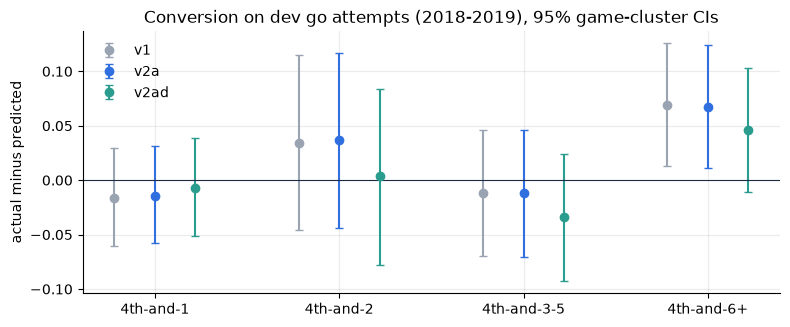

In [19]:
fig, ax = plt.subplots(figsize=(9, 3.4))
groups = ["4th-and-1", "4th-and-2", "4th-and-3-5", "4th-and-6+"]
for j, (k, col) in enumerate((("v1", MUTED), ("v2a", ACCENT), ("v2ad", MODEL))):
    sel = V2["candidates"][k]["selection"]
    x = np.arange(len(groups)) + (j - 1) * 0.22
    y = [sel[g]["actual_minus_pred"]["diff"] for g in groups]
    lo = [sel[g]["actual_minus_pred"]["ci_low"] for g in groups]
    hi = [sel[g]["actual_minus_pred"]["ci_high"] for g in groups]
    ax.errorbar(x, y, yerr=[np.subtract(y, lo), np.subtract(hi, y)], fmt="o", color=col, capsize=3, label=k)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(range(len(groups)), groups)
ax.set_ylabel("actual minus predicted")
ax.set_title("Conversion on dev go attempts (2018-2019), 95% game-cluster CIs")
ax.legend(frameon=False)
plt.show()

**Reading.** The original rule picked **v2a**, a small but real Brier gain over v1 that does not fix what failed: its ECE and its 4th-and-2 gap are v1's. The corrected rule picks **v2ad**: the v2a mix plus fourth-down offsets on each call's conversion odds. It goes after the actual source, taking 4th-and-2 from +0.034 to +0.004 and ECE from 0.033 to 0.019. Its dev weak spots are 4th-and-3-5 (over-predicted by 0.034) and 6+ (still under-predicted by 0.046).

**What is frozen.** v2ad for 2026, in `experiments/m7a_v2/frozen_2026.json`:
- the mix, fit on 2006-2025 go attempts;
- the offsets, fit out of fold on the M6 seasons 2016-2025 (training only; nothing is evaluated on 2020-2025).

The forward test scores it once on the 2026 regular season, after the 2026 participation file is out. With about 800 attempts the calibration band is wide (null p95 about 0.05), so a 2026-only pass is weak evidence. A pre-registered pooled 2026+2027 look (about 1,600 attempts) adds a 4th-and-1/2 gap rule (|gap| < 0.03).